# Analyse der Datensatzgröße & Datenbereinigung

## 1. Ursachen für die Reduzierung der Datenmenge auf 13.676 Einträge

Die Reduzierung des ursprünglichen "MovieLens 25M"-Datensatzes (der ca. 62.000 Filme umfasst) auf exakt **13.676 Filme** im bereinigten Datensatz resultiert aus notwendigen Filterungsschritten in der Daten-Pipeline:

- **Verfügbarkeit des Tag-Genomes**: Die für das Mood-Training essenziellen Stimmungs-Vektoren (das Tag-Genome) sind im MovieLens-Datensatz nur für knapp 14.000 Filme berechnet worden. Filme ohne diese Vektoren besitzen keine Labels und mussten über einen `inner join` entfernt werden.
- **Ausschluss fehlender Filmbeschreibungen**: Da das Modell lernen soll, aus Freitext Stimmungen vorherzusagen, ist eine Textbeschreibung zwingend erforderlich. Filme, für die aus TMDB keine Beschreibung (`overview`) geladen werden konnte, wurden herausgefiltert.

## 2. Eignung der verbleibenden Datenmenge für das Fine-Tuning

Obwohl 13.676 Datensätze für das Training eines neuronalen Netzes von Grund auf unzureichend wären, ist diese Menge für den gewählten Fine-Tuning-Ansatz gut geeignet:

- **Transfer Learning**: Das Projekt nutzt ein vortrainiertes Transformer-Modell (z. B. DistilBERT), das bereits über umfassendes sprachliches Vorwissen verfügt.
- **Optimaler Bereich (Sweet Spot)**: Für das Fine-Tuning eines solchen Modells gilt eine dichte, qualitativ hochwertige Datenbasis von 10.000 bis 20.000 Beispielen als ideal. Sie bietet ausreichend Varianz für robustes Lernen bei gleichzeitig sehr kurzen Trainingszeiten und minimalem Rauschen.

HuggingFace-Modell wurde hochgeladen. Lokales Training erfolgt über `uv run --no-sync python -m src.training.train_model`.


# Trainings- und Optimierungsnotizen

Dieser Abschnitt dokumentiert die Entwicklung der Trainingspipeline chronologisch: Ausgangslage, technische Anpassungen, Experimentreihen, aktuelles Ergebnis und die verbleibenden sinnvollen To-dos.

## 1. Ausgangslage: Daten und Label-Herkunft

Die Trainingsdaten entstehen aus einer Verknüpfung von TMDB-Filmbeschreibungen (`overview`) und MovieLens-Tag-Genome-Daten. `src/data/prepare_data.py` erzeugt daraus `cleaned_movie_data.csv` und `mood_tags.json`.

Aktuell werden die 100 häufigsten MovieLens-Genome-Tags ausgewählt, deren Relevanz mindestens `Settings.DECISION_THRESHOLD` erreicht. Diese Auswahl ist technisch nachvollziehbar, aber semantisch nicht streng auf Stimmungen begrenzt.

Dabei wurde sichtbar, dass `mood_tags.json` neben echten Mood-/Tone-Tags auch Genres, Plot-Merkmale, Produktionskontext, Auszeichnungen und formale Eigenschaften enthält, z. B. `action`, `oscar`, `pg-13`, `based on book`, `criterion`, `plot` oder `story`.

Damit trainiert das Modell derzeit eher einen Top-100-MovieLens-Tag-Predictor als einen reinen Mood-Predictor. Für den Prototyp ist das brauchbar, die spätere Empfehlungsqualität hängt jedoch stark von einer saubereren Label-Liste ab.


## 2. Laufzeitproblem: Sequenzlänge und Padding

Für den Bot wurde `MAX_SEQUENCE_LENGTH = 512` gesetzt, damit längere User-Anfragen nicht zu früh abgeschnitten werden. Beim Training war das zunächst teuer, weil die Tokenisierung mit `padding="max_length"` jedes Beispiel auf 512 Tokens aufgefüllt hat.

Die gemessenen Tokenlängen der aktuellen Trainingsdaten zeigen, dass diese fixe Auffüllung kaum Nutzen bringt:

- Mittelwert: ca. 62 Tokens
- Median: ca. 57 Tokens
- 95. Perzentil: ca. 119 Tokens
- 99. Perzentil: ca. 163 Tokens
- Maximum: ca. 235 Tokens
- Beispiele über 256 Tokens: 0

Anpassung: `dataset.py` tokenisiert ohne fixes Padding. `train_model.py` nutzt `DataCollatorWithPadding`, sodass pro Batch nur bis zur längsten Sequenz im Batch aufgefüllt wird. Damit bleiben lange Bot-Eingaben erlaubt, ohne kurze Trainingsbeispiele unnötig teuer zu machen.


## 3. Ausführung auf der CUDA-Maschine

Beim Training wurde beobachtet, dass `uv run` die Umgebung anhand von `uv.lock` wieder auf die CPU-Version von PyTorch synchronisieren kann. Dadurch kann ein zuvor manuell installiertes CUDA-PyTorch wieder überschrieben werden.

Auf der CUDA-Maschine wird deshalb zuerst synchronisiert, danach die passende Torch-Version installiert und anschließend mit `--no-sync` trainiert:

```powershell
uv sync
uv pip install torch --torch-backend=cu130 --reinstall
uv run --no-sync python -c "import torch; print(torch.__version__, torch.cuda.is_available())"
```

Das Script `run_selected_experiments.sh` verwendet intern bereits `uv run --no-sync`, damit diese Umgebung während der Experimentreihe stabil bleibt.


## 4. Erste Hyperparameter-Beobachtungen (vor Pipeline-Optimierungen)

Die erste grobe Experimentreihe zeigte, dass kleinere Batch Sizes deutlich besser funktionieren. Die Werte beziehen sich auf `eval_macro_f1` mit fixem Threshold `0.5`.

| Run | Bester eval_macro_f1 |
| --- | ---: |
| epochs=5, batch_size=8, lr=2e-5 | 0.291093 |
| epochs=5, batch_size=16, lr=2e-5 | 0.222505 |
| epochs=5, batch_size=24, lr=2e-5 | 0.207173 |
| epochs=5, batch_size=32, lr=2e-5 | 0.167727 |

Daraufhin wurde der Suchraum auf `batch_size=8` fokussiert. Die zweite ausgewählte Experimentreihe ergab vor den späteren Optimierungen:

| Run | Bester eval_macro_f1 | Bemerkung |
| --- | ---: | --- |
| epochs=8, batch_size=8, lr=2e-5 | 0.337729 | bester beobachteter Run vor den neuen Loss-/Threshold-Änderungen |
| epochs=5, batch_size=8, lr=3e-5 | 0.316420 | liegt aktuell als Baseline-Metadatenwert in `final_model/best_model_info.json` |
| epochs=6, batch_size=8, lr=2e-5 | 0.302998 | besser als 5 Epochen bei gleicher LR |
| epochs=5, batch_size=8, lr=2e-5 | 0.277513 | solide, aber unter 6/8 Epochen |
| epochs=5, batch_size=8, lr=1e-5 | 0.193982 | lernte zu langsam |

Aus diesen Runs ergab sich `batch_size=8` als bevorzugte Batch Size. Mehr Epochen halfen bis mindestens Epoche 6. `1e-5` lernte zu langsam; `3e-5` war bei 5 Epochen besser als `2e-5`. Vor den späteren Code-Optimierungen war `epochs=8, batch_size=8, lr=2e-5` der beste beobachtete Run.


## 5. Anpassungen an der Trainingspipeline

Danach wurde die Trainingspipeline verbessert, ohne die Label-Liste neu zu kuratieren:

1. **Learning Rate als CLI-Parameter**  
   `train_model.py` akzeptiert `--learning_rate`, damit Experimente ohne Codeänderung vergleichbar laufen.

2. **Dynamic Padding**  
   `dataset.py` tokenisiert ohne `padding="max_length"`; `train_model.py` nutzt `DataCollatorWithPadding`.

3. **Gewichtete Loss-Funktion**  
   `WeightedTrainer` verwendet `BCEWithLogitsLoss(pos_weight=...)`, damit seltenere positive Labels stärker berücksichtigt werden. Ziel ist eine bessere Macro-F1 über alle Labels, nicht nur über häufige Tags.

4. **Metriken mit Threshold-Tracking**  
   `macro_f1` bleibt der Score beim festen Threshold `0.5`. Zusätzlich scannt `compute_metrics()` globale Thresholds von `0.1` bis `0.9` und loggt den besten Wert als `macro_f1_best_threshold` sowie den zugehörigen `decision_threshold`.

5. **Zentrale Trainingskonfiguration**  
   Wichtige Stellschrauben wie Default-Epochen, Batch Size, Learning Rate, Test-Split, Warmup, Weight Decay, Checkpoint-Limit, Threshold-Suchbereich und `Settings.RANDOM_SEED` liegen jetzt in `Settings`. Der Seed steuert sowohl den Dataset-Split als auch `seed` und `data_seed` in `TrainingArguments`.

6. **Final-Model-Vergleich**  
   `final_model` wird nicht mehr nach jedem Run blind überschrieben. Stattdessen vergleicht `training_utils.py` den neuen besten `macro_f1` mit `final_model/best_model_info.json` und speichert nur bei Verbesserung.

Da `metric_for_best_model="macro_f1"` gesetzt ist, wird das finale Modell weiterhin nach dem festen Threshold `0.5` ausgewählt. Der optimierte Threshold ist aktuell ein Analysewert, keine Bot-Laufzeitlogik.


## 6. Ausgewählte Experimentreihe (nach Pipeline-Optimierungen)

Nach den Pipeline-Anpassungen wurde der Suchraum gezielt um die bisher besten Parameter gelegt. Das Script `run_selected_experiments.sh` führt diese Runs aus:

```text
epochs=10, batch_size=8, lr=2e-5
epochs=12, batch_size=8, lr=2e-5
epochs=8,  batch_size=8, lr=3e-5
epochs=10, batch_size=8, lr=3e-5
epochs=8,  batch_size=4, lr=2e-5
```

Startbefehl unter PowerShell:

```powershell
& "C:\\Program Files\\Git\\bin\\bash.exe" "./run_selected_experiments.sh"
```

Die wichtigsten TensorBoard-Kurven für die Auswertung sind:

- `eval/macro_f1`: Entscheidende Vergleichsmetrik bei Threshold `0.5`
- `eval/macro_f1_best_threshold`: bester F1 nach globalem Threshold-Scan
- `eval/decision_threshold`: bester gescannter Threshold
- `eval/roc_auc`: Rangordnungsqualität der Wahrscheinlichkeiten
- `eval/loss` und `train/loss`: Trainingsverlauf und Overfitting-Signale


## 7. Ergebnis der optimierten Experimentreihe

Die ausgewählte Experimentreihe ist vollständig durchgelaufen. Alle Runs haben TensorBoard-Scalars geschrieben, und `final_model` wurde auf den besten Run aktualisiert.

Bestes gespeichertes Modell laut `src/training/models/final_model/best_model_info.json`:

```json
{
    "best_macro_f1": 0.45365440070513957,
    "best_macro_f1_best_threshold": 0.45365440070513957,
    "best_decision_threshold": 0.5000000000000001,
    "metric_for_best_model": "macro_f1",
    "run_name": "run_20260530-165150-epochs8_bs8_lr3e-05",
    "epochs": 8,
    "batch_size": 8,
    "learning_rate": 3e-05,
    "best_global_step": 12312
}
```

Ranking der relevanten neuen Runs nach bestem `eval/macro_f1`:

| Rang | Run | Best macro_f1 | Threshold | ROC-AUC | Bemerkung |
| ---: | --- | ---: | ---: | ---: | --- |
| 1 | epochs=8, batch_size=8, lr=3e-5 | 0.453654 | 0.50 | 0.760650 | aktuelles `final_model` |
| 2 | epochs=10, batch_size=8, lr=3e-5 | 0.452060 | 0.50 | 0.760882 | fast gleich gut |
| 3 | epochs=10, batch_size=8, lr=2e-5 | 0.451697 | 0.50 | 0.759121 | fast gleich gut |
| 4 | epochs=8, batch_size=4, lr=2e-5 | 0.451503 | 0.50 | 0.757287 | ebenfalls nah dran, aber längere Laufzeit |
| 5 | epochs=12, batch_size=8, lr=2e-5 | 0.450305 | 0.45 | 0.757866 | etwas schwächer |

Beobachtungen:

- Der beste beobachtete `macro_f1` stieg von ca. `0.338` auf `0.454`.
- Die Top-Runs liegen sehr nah beieinander; `epochs=8, batch_size=8, lr=3e-5` ist aber zugleich der beste und einer der kürzeren Runs.
- Der beste Threshold liegt beim Gewinner bei `0.50`. Der Score hängt damit nicht von einem extrem niedrigen oder hohen Threshold ab.
- `ROC-AUC` liegt bei den Top-Runs um `0.76`. Positive Beispiele werden damit deutlich besser gerankt als durch Zufall, auch wenn die absolute F1 noch Raum nach oben lässt.
- `eval_loss` steigt bei einigen Runs, während `macro_f1` steigt. Die Modellwahl erfolgt deshalb nach der Zielmetrik und nach qualitativer Bot-Prüfung, nicht nur nach Loss.


## 8. Breite Grid-Suche mit `run_experiments.sh`

Nach der ausgewählten Experimentreihe wurde `run_experiments.sh` erneut ausgeführt. Das Script testet eine breitere Kombination aus Epochen und Batch Sizes bei `learning_rate=2e-5`:

```text
epochs in [5, 8, 10, 12]
batch_size in [8, 16, 24, 32]
learning_rate = 2e-5
```

Die Ausführung nutzt jetzt ebenfalls `uv run --no-sync`, damit die CUDA-PyTorch-Installation auf der Trainingsmaschine nicht durch einen erneuten Sync ersetzt wird.

Ranking der besten Runs aus dieser Grid-Suche nach `eval/macro_f1`:

| Rang | Run | Best macro_f1 | Threshold | ROC-AUC | Bemerkung |
| ---: | --- | ---: | ---: | ---: | --- |
| 1 | epochs=12, batch_size=8, lr=2e-5 | 0.451165 | 0.50 | 0.758470 | bester Run dieser Grid-Suche |
| 2 | epochs=5, batch_size=8, lr=2e-5 | 0.450603 | 0.50 | 0.759213 | sehr nah am besten Grid-Run |
| 3 | epochs=10, batch_size=8, lr=2e-5 | 0.449669 | 0.50 | 0.759020 | etwas schwächer |
| 4 | epochs=8, batch_size=8, lr=2e-5 | 0.448986 | 0.50 | 0.757398 | schwächer als der frühere 8/8/3e-5 Run |
| 5 | epochs=10, batch_size=16, lr=2e-5 | 0.447697 | 0.50 | 0.756973 | größere Batch Size bleibt schwächer |

Einordnung:

- Die breite Grid-Suche bestätigt `batch_size=8` als beste Batch Size im getesteten Bereich.
- Die beste Konfiguration dieser Grid-Suche erreicht `macro_f1=0.451165` und schlägt den vorherigen besten Run `epochs=8, batch_size=8, lr=3e-5` mit `macro_f1=0.453654` nicht.
- Die Ergebnisse stützen damit die vorherige Einordnung: Eine weitere breite Suche bei `lr=2e-5` bringt weniger Nutzen als gezielte Tests um `batch_size=8` und `lr=3e-5`.
- Das aktuell lokal gespeicherte `final_model` wurde durch diese Grid-Suche auf `run_20260530-184925-epochs12_bs8_lr2e-05` gesetzt. Dieses Modell ist besser als die anderen Grid-Runs, aber schlechter als der zuvor dokumentierte beste 8/8/3e-5-Run.


## 9. Aktueller Stand und Einordnung

Technisch funktioniert die Trainingspipeline jetzt durchgängig:

- Daten werden geladen und dynamisch gepaddet.
- Das Training nutzt eine gewichtete BCE-Loss für unausgeglichene Labels.
- Experimente können per CLI und Script gestartet werden; zentrale Trainingsdefaults und Seed liegen in `Settings`.
- Das beste Modell wird nicht mehr versehentlich durch schlechtere Runs überschrieben.
- Das aktuelle `final_model` lädt erfolgreich in der Inferenz und erzeugt Empfehlungen.

Fachlich bleibt aber die Label-Definition der größte Hebel. Ein guter `macro_f1` auf den aktuellen Labels bedeutet, dass das Modell die ausgewählten MovieLens-Genome-Tags besser trifft. Es bedeutet noch nicht automatisch, dass die Filmempfehlungen nach menschlichem Mood-Verständnis optimal sind.

Der Bot nutzt aktuell keine binären Tag-Entscheidungen, sondern die Wahrscheinlichkeitsvektoren des Modells und vergleicht sie per Cosine Similarity mit den Filmvektoren. Der getrackte Threshold dient daher der Trainingsanalyse, ist aber nicht direkt Teil der Bot-Logik.

Aus dem aktuellen Stand folgt: Weitere breite Hyperparameter-Suchen haben wahrscheinlich weniger Nutzen als eine qualitative Bot-Evaluation und eine bessere Mood-Tag-Definition. Falls das beste bisher beobachtete Modell lokal wieder als `final_model` liegen soll, muss `epochs=8, batch_size=8, learning_rate=3e-5` erneut trainiert werden.


## 10. Datenbasis nach Tag-Refactor

Die offene Label-Kuratierung wurde anschließend in der Datenpipeline umgesetzt. Aus `mood_tags.json` wurde fachlich neutraler `movie_tags.json`, weil die Tags nicht nur Stimmungen, sondern auch Genres, Tonalität, Plot-Merkmale, Strukturmerkmale, Auszeichnungen und Qualitätsurteile enthalten.

Wesentliche Änderungen:

- `Settings.MOVIE_TAG_COUNT = 150`: Die ausgewählte Label-Liste wurde von 100 auf 150 Tags erweitert.
- `Settings.MOVIE_TAGS_PATH`: Die Tag-Liste heißt jetzt `src/data/movie_tags.json`; `create_movie_tag_list()` ersetzt die alte Mood-Benennung.
- `src/data/tag_alias_groups.json`: Semantisch gleiche Genome-Tags werden konfigurierbar zusammengeführt, ohne Python-Code anzupassen, z. B. `based on a book` und `adapted from:book` zu `based on book`.
- `cleaned_movie_data.csv` enthält jetzt zusätzlich `movieId` und `tmdbId`, damit Empfehlungen und Datenfehler besser nachvollziehbar sind.
- Die Pipeline filtert harte Dubletten über IDs sowie echte `title + overview`-Dubletten. Reine Titelgleichheiten bleiben erhalten, weil Remakes oder verschiedene Filme denselben Titel haben können.
- `src/data/data_quality_report.json` dokumentiert Input-Größen, entfernte Zeilen, Dubletten, ausgewählte Tags und Label-Verteilungen.

Der aktuelle generierte Datensatz enthält:

- 13.670 Filme
- 150 eindeutige Movie-Tags
- 150 Labels pro Film
- keine leeren Texte
- keine doppelten `movieId`- oder `tmdbId`-Werte
- keine doppelten `title + text`-Kombinationen

Die neue Tag-Liste enthält weiterhin echte Mood-/Tone-Tags wie `atmospheric`, `bittersweet`, `bleak`, `creepy`, `dark`, `feel-good`, `funny`, `intense`, `melancholic`, `suspense`, `tense` oder `touching`. Sie ist aber bewusst keine reine Mood-Liste mehr, sondern eine gemischte Movie-Tag-Liste.

Ein Training-Dry-Run mit `uv run --no-sync python -m src.training.train_model --dry_run` lief erfolgreich durch. Der dabei erzeugte Checkpoint hatte 150 Labels (`id2label_len=150`, `label2id_len=150`). Das vorhandene `final_model` basiert dagegen noch auf der alten 100-Label-Struktur und ist nach der Umstellung nicht mehr kompatibel. Vor produktiver Bot-Nutzung ist deshalb ein vollständiges Neutraining erforderlich.


## 11. Bot-Handling und Mistral-Chat-Schicht

Nach der Trainings- und Recommender-Arbeit wurde das Telegram-Bot-Handling überarbeitet und im Merge auf die neue `movie_tags`-Benennung angepasst. Wichtig ist dabei, die bestehende Empfehlungslogik nicht zu ersetzen: `MovieTagPredictor` und `MovieRecommender` bleiben für die Filmauswahl verantwortlich. Mistral wird nur als Chat-Schicht davor und als Antwort-Schicht danach genutzt.

Chronologie der Änderungen:

1. **Problem im Bot-Verhalten identifiziert**  
   Der Bot hat jede Textnachricht direkt an `predictor.predict(...)` übergeben. Dadurch erzeugten Eingaben wie `+`, `#`, `gre` oder `erb` trotzdem einen Wahrscheinlichkeitsvektor. Da der Recommender immer die nächsten Filme per Cosine Similarity findet, entstanden scheinbar gültige Empfehlungen für inhaltlich ungültige Eingaben.

2. **Erster lokaler Eingabe-Guard eingebaut**  
   In `src/telegram_bot/bot.py` wurden `normalize_user_message(...)` und `is_valid_movie_request(...)` ergänzt. Damit wurden leere Nachrichten und reine Symbol-Eingaben früh abgefangen. Diese lokale Intent-Prüfung war ein Zwischenstand und wurde später durch die verpflichtende Mistral-Schicht ersetzt.

3. **Grenze des bestehenden Modells geklärt**  
   Das trainierte Modell ist ein Movie-Tag-Predictor. Es besitzt keine Klasse für `invalid_request`, `not_movie_related` oder `nonsense`. Deshalb kann es nicht verlässlich selbst entscheiden, ob eine Anfrage sinnvoll ist. Die hohen Prozentwerte im Bot sind keine Modell-Confidence, sondern Ähnlichkeitswerte zwischen User-Vektor und Filmvektoren.

4. **Mistral als ChatController eingeführt**  
   Mit `src/telegram_bot/chat_controller.py` wurde eine separate Controller-Schicht eingeführt. Sie ruft die Mistral Chat-Completions API über die Standardbibliothek auf und liefert eine strukturierte Entscheidung mit festen Actions: `recommend`, `clarify`, `reject`, `help` und `smalltalk`.

5. **Strukturierte Entscheidungen statt freier LLM-Antworten**  
   Der Controller nutzt `response_format` mit JSON-Schema. Bei `recommend` gibt Mistral eine bereinigte `cleaned_query` zurück, die anschließend an `MovieTagPredictor` übergeben wird. Wenn die Anfrage nicht auf Englisch gestellt ist, kann Mistral die fachliche Suchintention für das Modell in eine englische Query normalisieren; Antworten an den User sollen aber in der Sprache der Anfrage bleiben.

6. **Konfiguration ergänzt**  
   In `src/settings.py` wurden `MISTRAL_API_KEY`, `MISTRAL_MODEL`, `MISTRAL_API_URL` und `MISTRAL_TIMEOUT_SECONDS` aufgenommen. `.env.template` und `README.md` dokumentieren `MISTRAL_API_KEY` und `MISTRAL_MODEL=mistral-small-latest`. Im aktuellen Stand ist `MISTRAL_API_KEY` verpflichtend; fehlt der Key, bricht `Settings.validate()` den Start ab.

7. **Bot-Flow umgestellt**  
   Der Ablauf ist jetzt: Telegram-Nachricht -> Mistral-Entscheidung -> nur bei `action == "recommend"` Aufruf von `MovieTagPredictor` und `MovieRecommender`. Bei `reject`, `clarify`, `help` oder `smalltalk` antwortet der Bot direkt, ohne das Empfehlungsmodell zu belasten.

8. **Antwortformatierung mit Mistral ergänzt**  
   Nach der Empfehlungserzeugung bekommt Mistral die fertigen Recommendations mit Titel, Score und Overview. Die Filmauswahl bleibt unverändert aus dem Recommender. Mistral liefert die lokalisierte Präsentation: einen Einstiegssatz und kurze Beschreibungen in der Antwortsprache.

9. **Formatter robuster gemacht**  
   Der erste Versuch ließ Mistral die komplette finale Antwort schreiben. Dabei konnte die eigentliche Liste fehlen. Deshalb wurde der Formatter angepasst: Mistral schreibt strukturierte Antwortteile (`intro` plus lokalisierte Item-Overviews), während `bot.py` Titel, Rang und Reihenfolge deterministisch zusammensetzt. Die internen Ähnlichkeitswerte werden nicht mehr in der Bot-Antwort angezeigt, weil sie für Nutzer wenig hilfreich sind.

10. **Decision-Logging aktiviert**  
    In `bot.py` wird jede Chat-Entscheidung mit `action` und `cleaned_query` geloggt. In `main.py` wurde `logging.basicConfig(level=logging.INFO, ...)` eingerichtet, damit diese Logs in der Konsole bzw. im Docker-Log sichtbar sind. Damit lässt sich prüfen, ob Mistral Anfragen sauber routet und ungültige Eingaben vom Empfehlungsmodell fernhält.

Aktueller Bot-Ablauf:

```text
Telegram message
-> Mistral ChatController
   -> reject / clarify / help / smalltalk: direkte Bot-Antwort
   -> recommend: cleaned_query
-> MovieTagPredictor(cleaned_query)
-> MovieRecommender
-> Mistral schreibt Intro und lokalisierte Kurzbeschreibungen
-> Bot setzt Titel, Rang und Reihenfolge deterministisch zusammen
```

Einordnung: Das Chat-Handling ist dadurch robuster, ohne die Sprache der Nutzeranfrage hart einzuschränken. Die Qualität der ausgewählten Filme hängt weiterhin vom trainierten Modell, den Labels und den Filmvektoren ab. Die Mistral-Schicht verbessert also die Chat-Steuerung und Präsentation, nicht die fachliche Qualität der Recommender-Ergebnisse.


## 12. Vollständiges Training nach Tag-Refactor

Nach der Umstellung von 100 `mood_tags` auf 150 `movie_tags` wurde am 12.06.2026 eine neue Experimentreihe mit der aktuellen Datenbasis ausgeführt. Diese Ergebnisse stehen chronologisch nach dem Daten-Refactor und der Bot-/Mistral-Anpassung, weil erst danach wieder ein kompatibles `final_model` erzeugt wurde.

Die TensorBoard-Rohdaten liegen weiterhin unter `src/training/models/logs`. Zusätzlich wurden die Scalars für die Dokumentation nach `src/training/models/exports/tensorboard_scalars_20260612.csv` exportiert. Die folgenden Abbildungen sind statische Exporte aus denselben TensorBoard-Eventdaten, damit die Kurven auch ohne laufendes TensorBoard im Notebook sichtbar bleiben.

Ranking der aktuellen Runs nach bestem `eval/macro_f1`:

| Rang | Run | Best macro_f1 | Epoch | Threshold | ROC-AUC | Eval-Loss | Bemerkung                                            |
| --- | --- | ---: | ---: | ---: | ---: | ---: |------------------------------------------------------|
| 1 | `epochs=10, batch_size=8, lr=3e-5` | 0.426110 | 10 | 0.50 | 0.771067 | 1.197269 | aktuelles `final_model`                              |
| 2 | `epochs=8, batch_size=4, lr=2e-5` | 0.420045 | 8 | 0.55 | 0.770214 | 1.127964 | besser als die `lr=2e-5`/`bs=8`-Runs, aber langsamer |
| 3 | `epochs=8, batch_size=8, lr=3e-5` | 0.418821 | 3 | 0.55 | 0.774926 | 0.977518 | beste ROC-AUC, aber nicht bester Zielscore           |
| 4 | `epochs=12, batch_size=8, lr=2e-5` | 0.418333 | 12 | 0.50 | 0.764531 | 1.186653 | längeres Training verbessert den Score nur leicht    |
| 5 | `epochs=10, batch_size=8, lr=2e-5` | 0.416535 | 7 | 0.55 | 0.767571 | 1.076375 | schwächster aktueller Run                            |

Bestes gespeichertes Modell laut `src/training/models/final_model/best_model_info.json`:

```json
{
    "best_macro_f1": 0.4261098927124068,
    "best_macro_f1_best_threshold": 0.4261098927124068,
    "best_decision_threshold": 0.5000000000000001,
    "metric_for_best_model": "macro_f1",
    "run_name": "run_20260612-110838-epochs10_bs8_lr3e-05",
    "epochs": 10,
    "batch_size": 8,
    "learning_rate": 3e-05,
    "best_global_step": 15380
}
```

Die wichtigsten TensorBoard-Scalars sind unten einzeln dargestellt, damit jede Kurve eindeutig einer Metrik zugeordnet ist. Innerhalb jeder Abbildung werden nur die Runs miteinander verglichen.

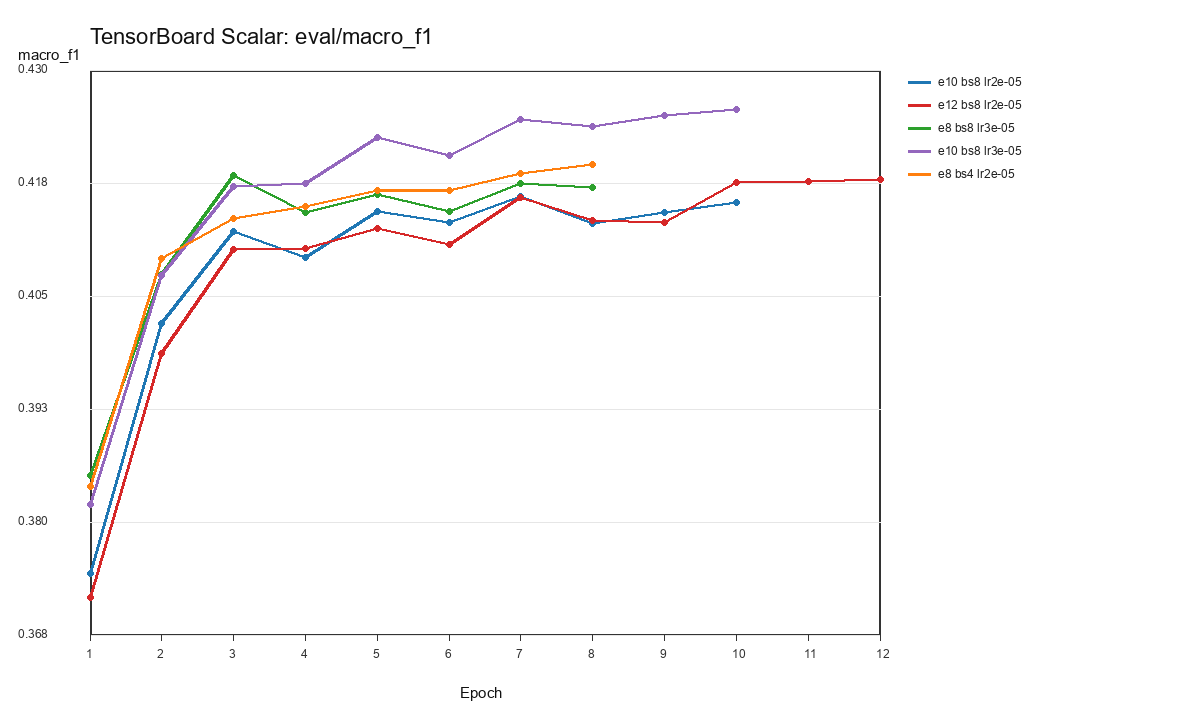

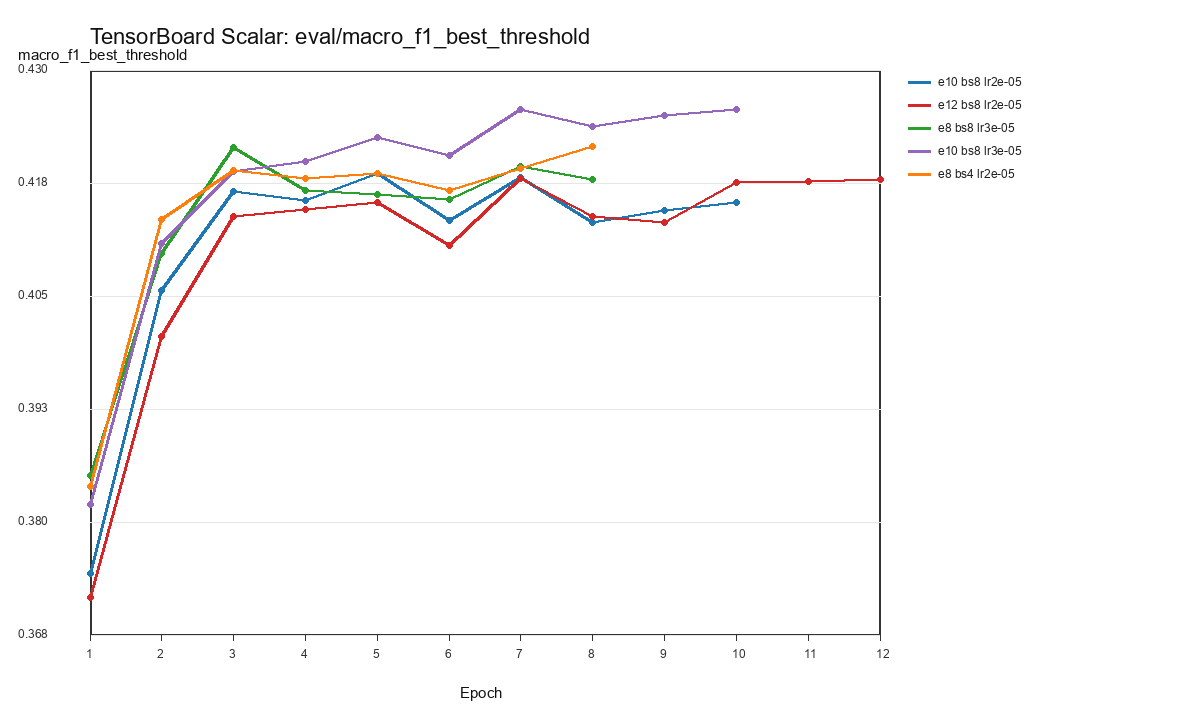

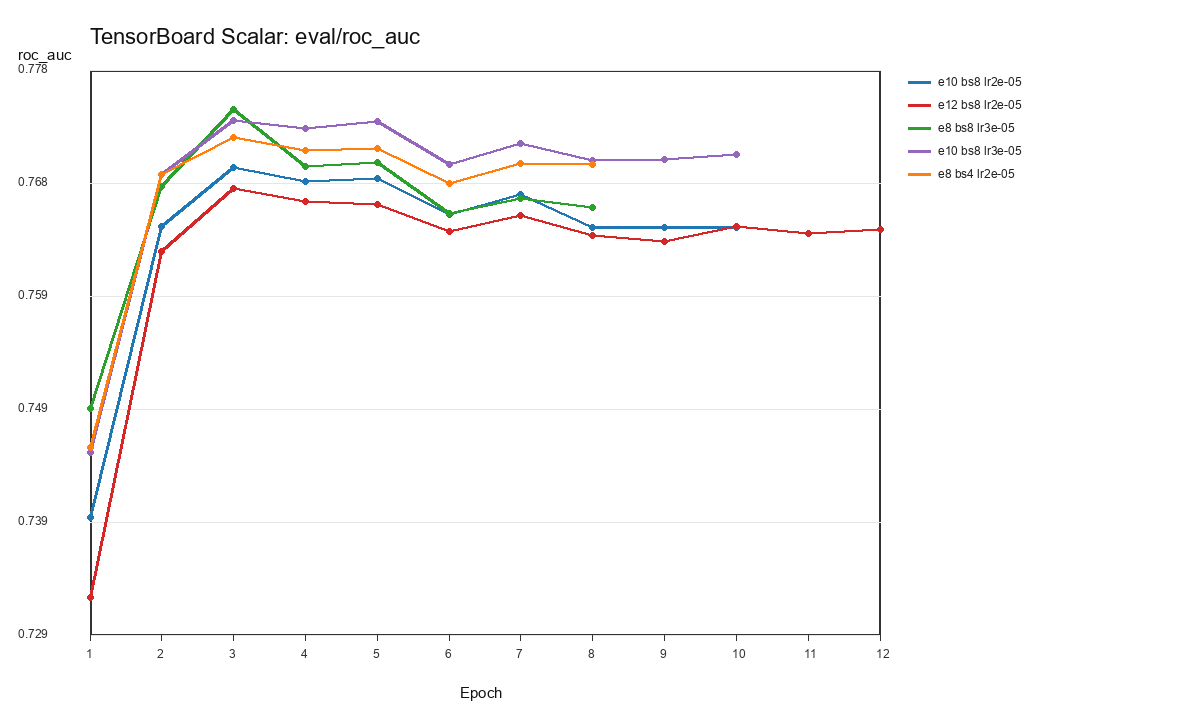

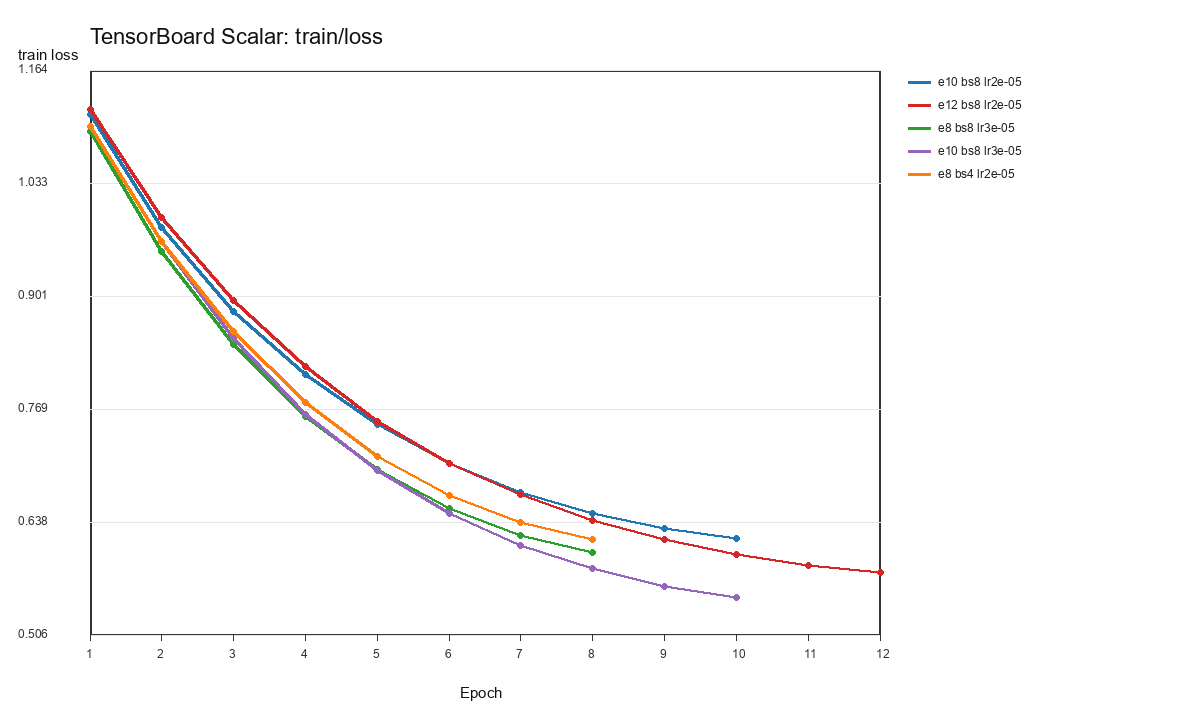

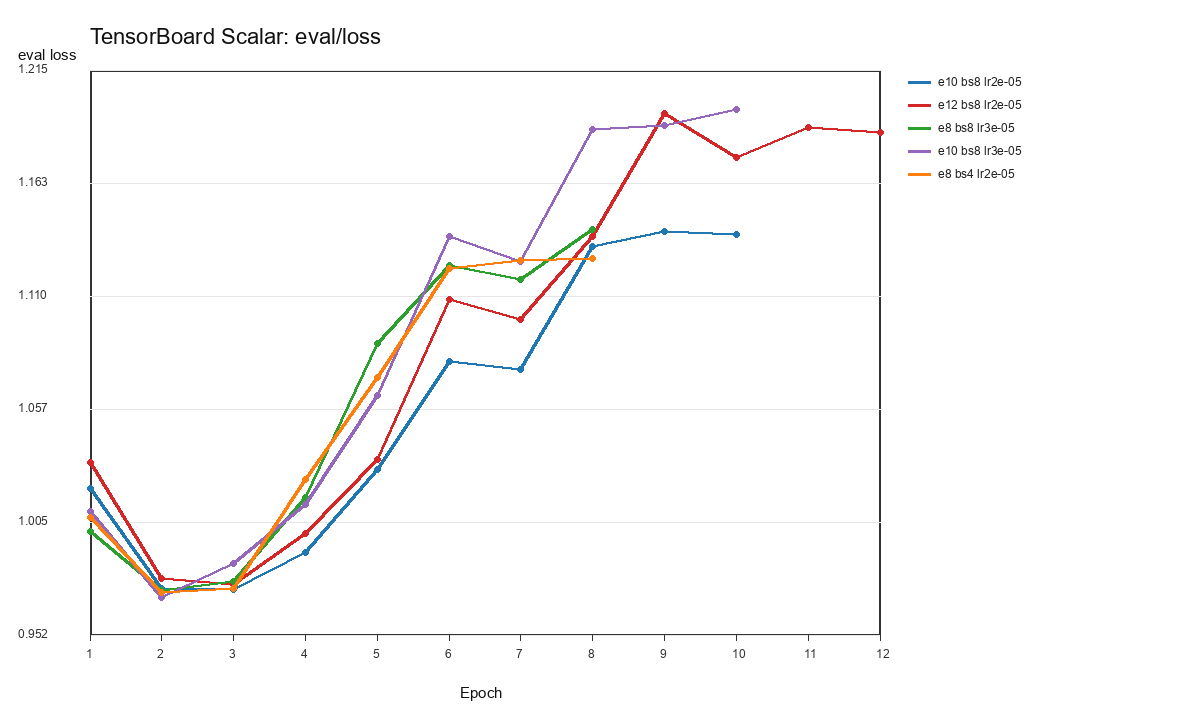

Einordnung:

- Das neue 150-Label-Modell ist wieder kompatibel mit der aktuellen Pipeline und wurde als `final_model` gespeichert.
- Die alten Scores aus der 100-Label-Phase sind wegen der geänderten Label-Struktur nicht mehr direkt vergleichbar. Der relevante neue Referenzwert ist `macro_f1=0.426110`.
- `lr=3e-5` mit `batch_size=8` bleibt im aktuellen Suchraum die stärkste Konfiguration. Der beste Run erreicht seinen höchsten Zielscore erst bei Epoch 10.
- Der optimierte Threshold liefert diesmal keinen zusätzlichen Vorteil für den besten Run; `best_decision_threshold` liegt praktisch wieder bei `0.5`.
- Die Loss-Kurven zeigen weiter, dass niedriger `eval_loss` nicht automatisch den besten `macro_f1` bedeutet. Die Modellauswahl bleibt deshalb korrekt auf `metric_for_best_model="macro_f1"` ausgerichtet.


## 13. Datensatzbereinigung gegen überbreite Film-Tag-Vektoren

Bei der qualitativen Prüfung der Empfehlungen fiel `Passchendaele` als wiederkehrender Fehlvorschlag auf. Die Zeile in `cleaned_movie_data.csv` hatte 127 positive Labels von 150, während der Median im Datensatz bei 19 positiven Labels lag. Solche fast vollständig positiven Vektoren wirken in der Cosine-Similarity des Recommenders wie Universal-Matches und können dadurch bei sehr unterschiedlichen Prompts weit oben erscheinen.

Die Datenpipeline wurde deshalb in `src/data/prepare_data.py` gezielt verschärft:

1. **Getrennte Schwellenwerte für Tag-Auswahl und Label-Binarisierung**  
   `Settings.TAG_SELECTION_THRESHOLD = 0.5` bestimmt weiterhin, welche Genome-Tags häufig genug sind, um in die 150er-Tag-Liste zu kommen. `Settings.LABEL_POSITIVE_THRESHOLD = 0.7` entscheidet jetzt strenger, wann ein Tag für einen konkreten Film als positives Label gilt. Dadurch werden schwach passende Genome-Scores nicht mehr automatisch zu Trainingslabels.

2. **Filter gegen zu dünne und zu dichte Label-Vektoren**  
   Nach dem Pivot der Genome-Scores entfernt die Pipeline Filme mit weniger als `Settings.MIN_POSITIVE_TAGS_PER_MOVIE = 2` oder mehr als `Settings.MAX_POSITIVE_TAGS_PER_MOVIE = 50` positiven Tags. Extrem breite Vektoren wie der beobachtete `Passchendaele`-Fall gelangen dadurch nicht mehr in Training und Recommender-Datenbasis.

3. **Mindestqualität für TMDB-Overviews**  
   `Settings.MIN_OVERVIEW_WORDS = 12` filtert sehr kurze Beschreibungen heraus. Damit sollen fragmentarische oder kaum informative Texte nicht als Trainingsbeispiele verwendet werden.

4. **Erweiterter Data-Quality-Report**  
   `data_quality_report.json` dokumentiert nun die neuen Settings, die Anzahl entfernter Kurztexte, die Anzahl entfernter Filme mit zu wenigen bzw. zu vielen positiven Labels und die Label-Dichte nach der Bereinigung (`median`, `p90`, `p95`, `p99`, `max`). Damit ist nach jedem Prepare-Run nachvollziehbar, ob die neue Datenbasis plausibel verteilt ist.

Der anschließende Prepare-Run mit `uv run --no-sync python -m src.data.prepare_data` erzeugte folgende neue Datenbasis:

| Kennzahl | Wert |
| --- | ---: |
| Filme in `cleaned_movie_data.csv` | 12.495 |
| Tags in `movie_tags.json` | 150 |
| Entfernt wegen zu weniger positiver Labels | 1.091 |
| Entfernt wegen zu vieler positiver Labels | 21 |
| Entfernte TMDB-Rohzeilen wegen zu kurzer Overview | 143.785 |
| Doppelte Titel nach Genome-Join | 489 |

Label-Dichte nach der Bereinigung:

| Metrik | Positive Labels pro Film |
| --- | ---: |
| Minimum | 2 |
| Median | 7 |
| p90 | 19 |
| p95 | 24 |
| p99 | 37 |
| Maximum | 50 |

`Passchendaele` ist in der neuen `cleaned_movie_data.csv` nicht mehr enthalten. Es gibt keine Filme mehr mit mehr als 50 positiven Tags; drei Filme liegen genau am Cap von 50. Damit ist der konkrete Universal-Match-Ausreißer behoben und die Filmvektoren sind deutlich sparsamer als zuvor.

Da sich die Label-Verteilung deutlich geändert hat, ist anschließend ein neues Training erforderlich; alte Scores und Empfehlungen sind nicht mehr direkt vergleichbar.


## 14. Ausgewählte Experimentreihe nach Datensatzbereinigung

Nach der Bereinigung der Label-Vektoren ist die Datenbasis fachlich nicht mehr direkt mit den vorherigen Trainingsläufen vergleichbar. Die Anzahl der Filme sank auf 12.495 und die Label-Dichte wurde deutlich sparsamer (`median=7`, `p95=24`, `max=50`). Deshalb wird nicht das alte `final_model` weiterverwendet, sondern mit der neuen CSV erneut trainiert.

Die bisherigen Experimente zeigten über mehrere Phasen hinweg, dass `batch_size=8` am stabilsten war. Größere Batch Sizes waren in der breiten Suche schwächer, und `batch_size=4` war zwar konkurrenzfähig, aber langsamer und nicht der beste Run. Deshalb bleibt die neue Suche eng auf `batch_size=8` fokussiert, statt wieder breit über Batch Sizes zu suchen.

`run_selected_experiments.sh` testet nach der Bereinigung diese Konfigurationen:

```text
epochs=6,  batch_size=8, lr=3e-5
epochs=8,  batch_size=8, lr=3e-5
epochs=10, batch_size=8, lr=3e-5
epochs=10, batch_size=8, lr=2e-5
epochs=12, batch_size=8, lr=2e-5
```

Begründung:

- `lr=3e-5` mit `batch_size=8` war in der letzten 150-Label-Experimentreihe der stärkste Bereich; deshalb werden 6, 8 und 10 Epochen getestet.
- `epochs=6` ist neu aufgenommen, weil die strengeren Labels sparsamer sind und das Modell möglicherweise früher einen guten Punkt erreicht.
- `lr=2e-5` bleibt mit 10 und 12 Epochen als konservativer Vergleich erhalten, falls die strengere Label-Binarisierung mit niedrigerer Lernrate stabiler läuft.
- Der alte `epochs=8, batch_size=4, lr=2e-5`-Run wurde entfernt, weil er mehr Laufzeit kostet, ohne bisher den besten Score geliefert zu haben.

Nach der neuen Datenbasis ist der relevante Vergleich wieder `eval/macro_f1` bei festem Threshold `0.5`; `eval/macro_f1_best_threshold`, `eval/decision_threshold`, `eval/roc_auc` und die Loss-Kurven bleiben zusätzliche Diagnosewerte. Die resultierenden Scores sollten nicht gegen die alten Pre-Cleanup-Werte bewertet werden, sondern nur innerhalb dieser neuen Experimentreihe.


## 15. Training nach Datensatzbereinigung

Nach der Bereinigung der Film-Tag-Vektoren wurde `run_selected_experiments.sh` erneut ausgeführt. Das alte `final_model` wurde vorher separat gesichert, damit die neuen Scores nicht gegen die alte Datenbasis verglichen werden. Das neu gespeicherte `final_model` ist kompatibel mit der aktuellen 150-Tag-Struktur (`config.id2label=150`, `movie_tags.json=150`).

Ranking der neuen Runs nach bestem `eval/macro_f1`:

| Rang | Run | Best macro_f1 | Best threshold F1 | Threshold | ROC-AUC | Eval-Loss | Train-Loss | Bemerkung |
| ---: | --- | ---: | ---: | ---: | ---: | ---: | ---: | --- |
| 1 | `epochs=10, batch_size=8, lr=3e-5` | 0.271452 | 0.282228 | 0.75 | 0.791184 | 1.432210 | 0.482497 | aktuelles `final_model` |
| 2 | `epochs=12, batch_size=8, lr=2e-5` | 0.262962 | 0.284236 | 0.70 | 0.791255 | 1.317492 | 0.519189 | bester optimierter Threshold-F1 |
| 3 | `epochs=8, batch_size=8, lr=3e-5` | 0.261956 | 0.284001 | 0.70 | 0.792914 | 1.257820 | 0.553008 | beste ROC-AUC |
| 4 | `epochs=10, batch_size=8, lr=2e-5` | 0.257226 | 0.282299 | 0.70 | 0.787365 | 1.247623 | 0.573470 | konservativer Vergleich |
| 5 | `epochs=6, batch_size=8, lr=3e-5` | 0.252808 | 0.281250 | 0.75 | 0.791915 | 1.132299 | 0.648185 | kürzester Run, aber schwächster fester F1 |

Bestes gespeichertes Modell laut `src/training/models/final_model/best_model_info.json`:

```json
{
    "best_macro_f1": 0.2714517123923183,
    "best_macro_f1_best_threshold": 0.2822276159036817,
    "best_decision_threshold": 0.7500000000000002,
    "metric_for_best_model": "macro_f1",
    "run_name": "run_20260612-122223-epochs10_bs8_lr3e-05",
    "epochs": 10,
    "batch_size": 8,
    "learning_rate": 3e-05,
    "best_global_step": 14060
}
```

Einordnung:

- Der beste feste `macro_f1` fällt gegenüber der vorherigen Datenbasis deutlich von `0.426110` auf `0.271452`. Das ist erwartbar, weil die Labels durch `LABEL_POSITIVE_THRESHOLD=0.7` und den Dichtefilter deutlich sparsamer und damit schwerer zu treffen sind. Die Werte sind nicht direkt mit den alten Scores vergleichbar.
- Gleichzeitig steigt `ROC-AUC` auf etwa `0.79` und liegt damit über den vorherigen ca. `0.77`. Das Modell rankt positive Labels also besser, auch wenn der feste Threshold `0.5` weniger gut zur neuen Label-Verteilung passt.
- Der beste gescannte Threshold liegt jetzt bei `0.70` bis `0.75`, nicht mehr bei `0.5`. Das passt zur strengeren Label-Binarisierung: positive Labels sind seltener und sollten für binäre Auswertung erst bei höherer Modellwahrscheinlichkeit gesetzt werden.
- `epochs=10, batch_size=8, lr=3e-5` bleibt auch nach der Bereinigung der beste Run nach der offiziellen Auswahlmetrik `macro_f1` bei Threshold `0.5`.
- `epochs=8, batch_size=8, lr=3e-5` hat die beste ROC-AUC und fast denselben optimierten Threshold-F1 wie die längeren Runs. Für Ranking-basierte Empfehlungen per Cosine Similarity könnte dieser Run qualitativ ähnlich oder sogar besser wirken, obwohl er nicht als `final_model` gespeichert wurde.
- Die Loss-Werte sinken bei kürzeren bzw. langsameren Runs, liefern aber nicht den besten `macro_f1`. Die Modellauswahl bleibt deshalb weiterhin sinnvoll auf `metric_for_best_model="macro_f1"` ausgerichtet.

Für die Bot-Qualität ist jetzt besonders wichtig, die Empfehlungen qualitativ zu prüfen. Der Bot nutzt keine harten binären Tags, sondern Wahrscheinlichkeitsvektoren; deshalb können `ROC-AUC` und reale Top-Empfehlungen wichtiger sein als der absolute feste `macro_f1`.

Die wichtigsten TensorBoard-Scalars der Cleanup-Experimentreihe sind zusätzlich als statische Ausschnitte eingebettet. Die Kurven stammen aus den Eventdaten unter `src/training/models/logs` und vergleichen nur die fünf Runs nach der Datensatzbereinigung.

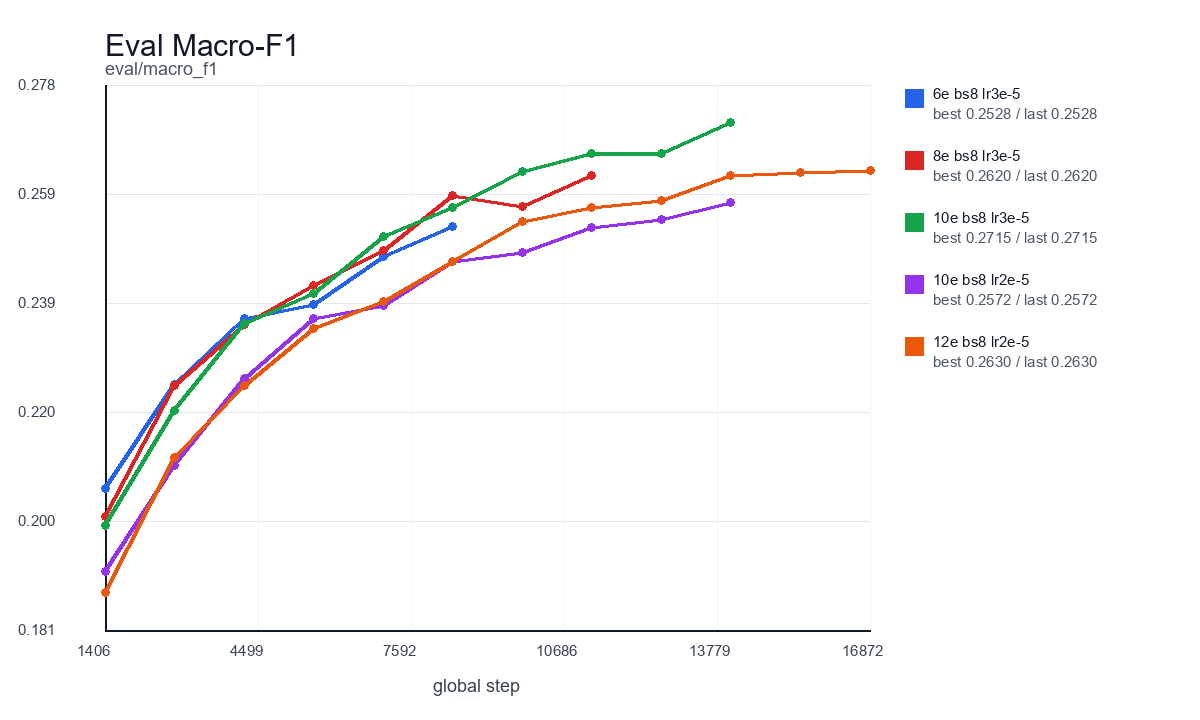

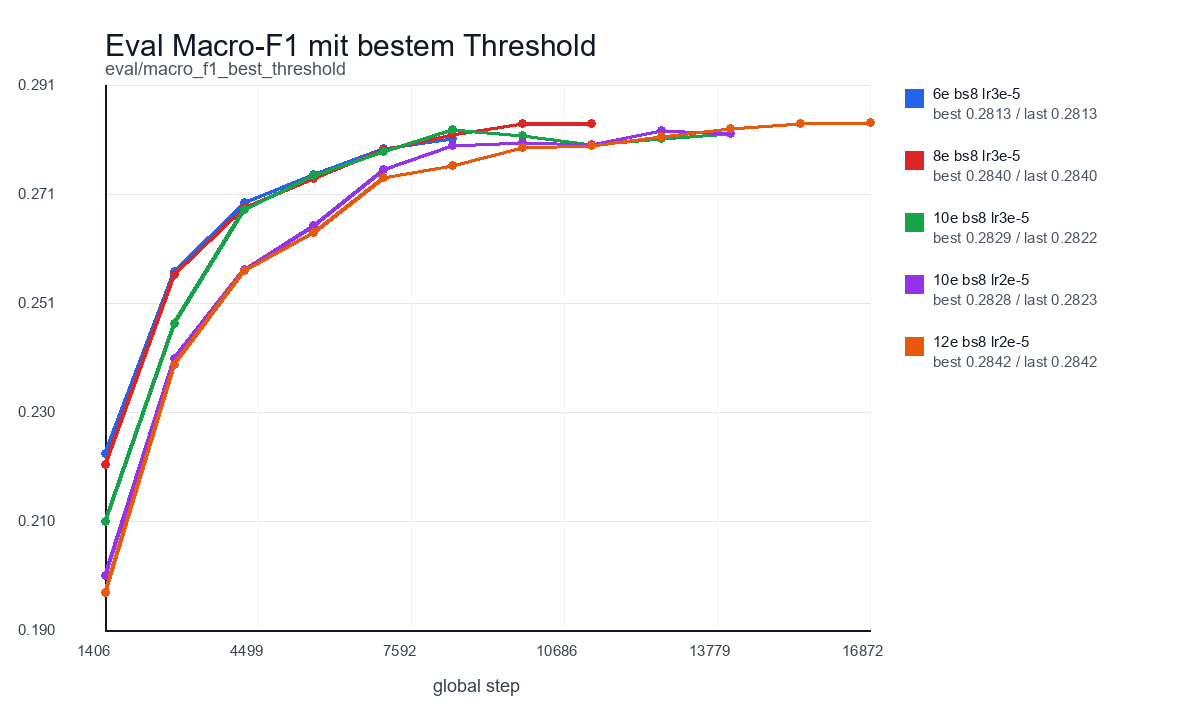

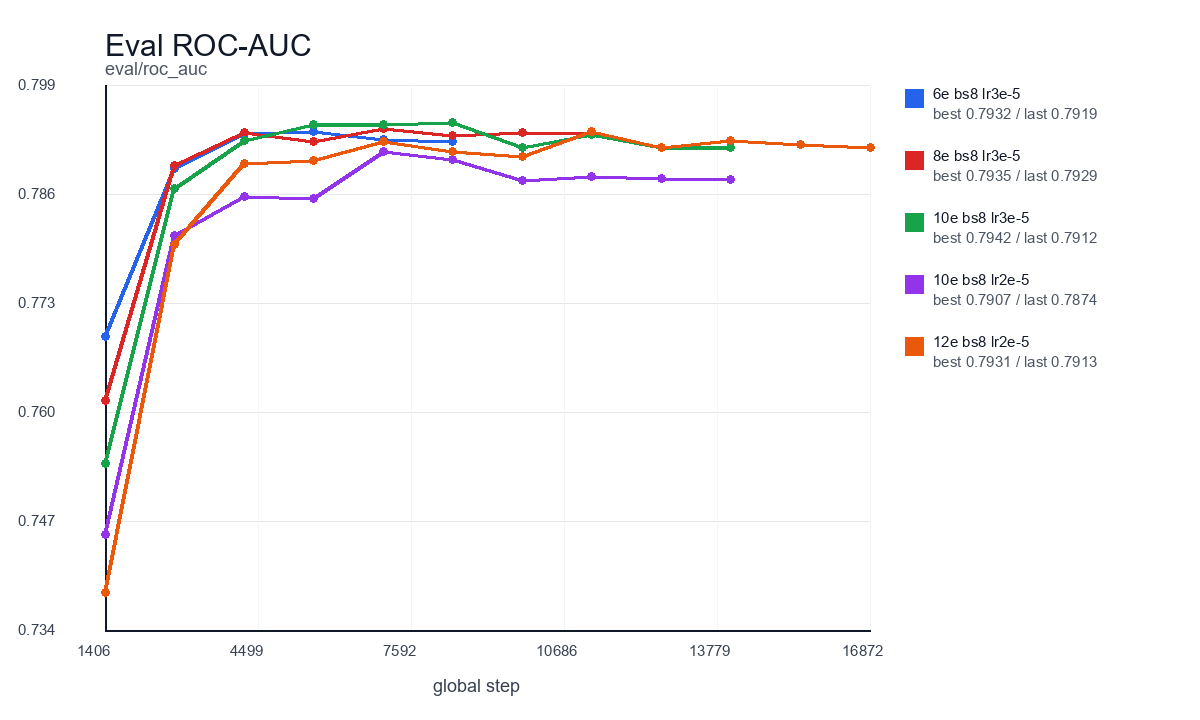

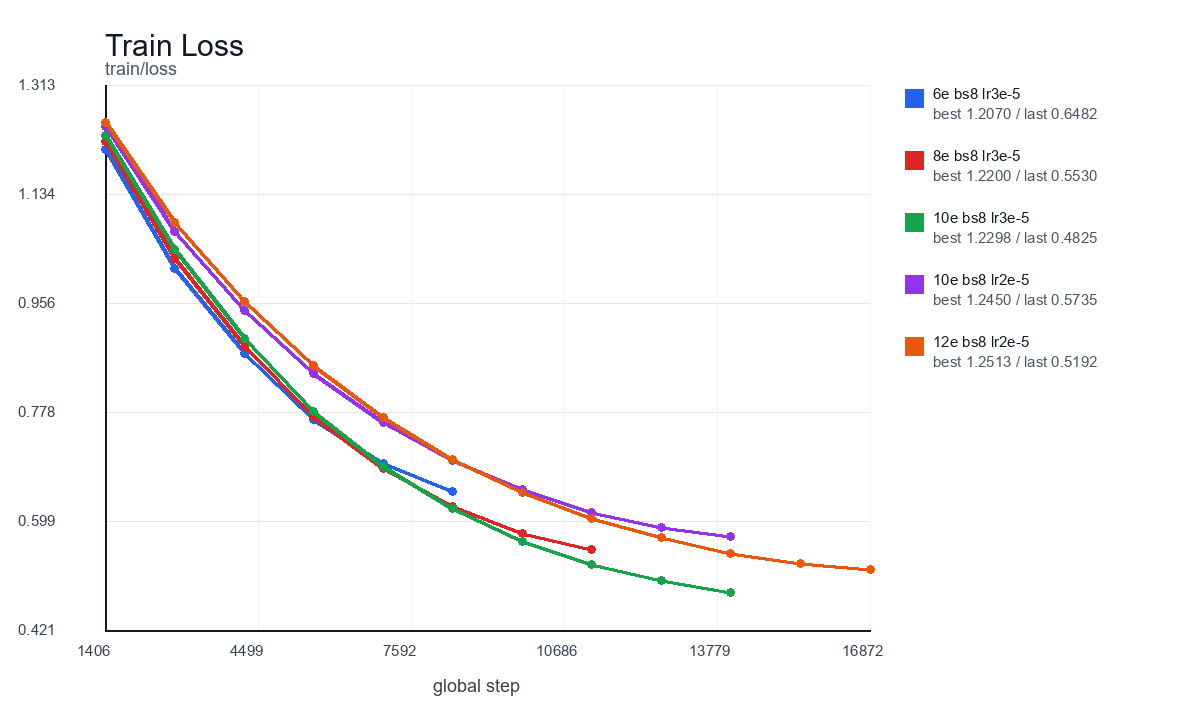

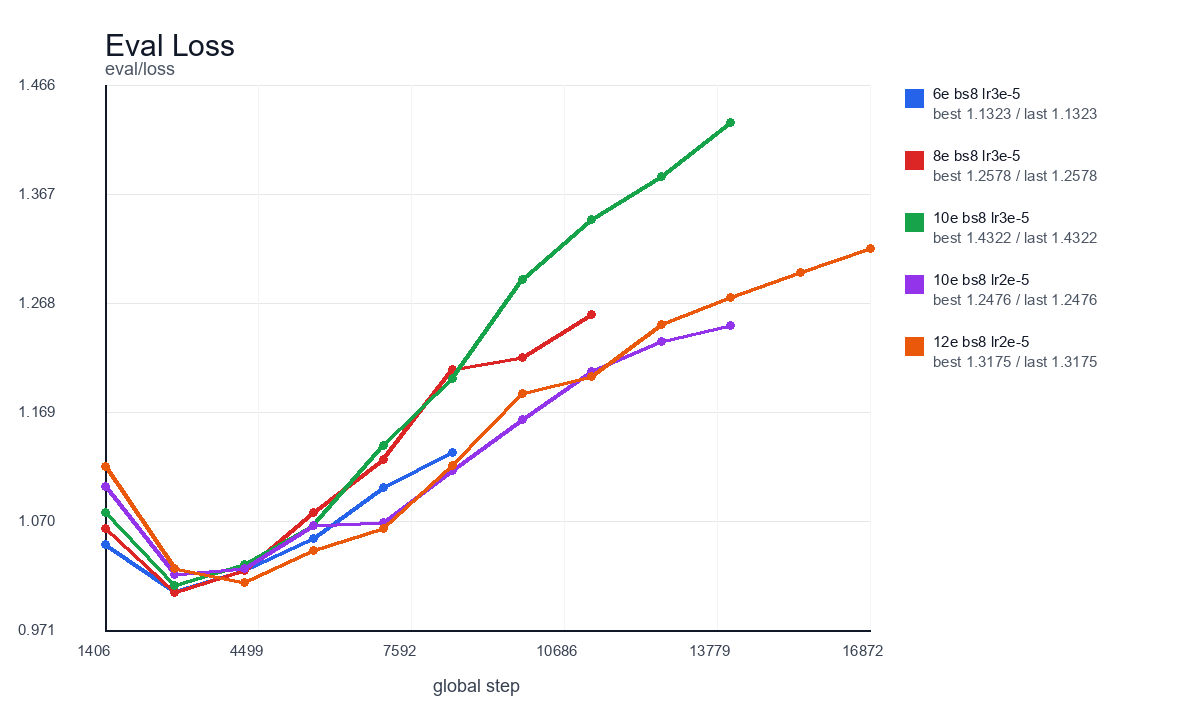


## 16. Recommender-Verbesserung: Titel-Erkennung und Hybrid-Ranking

Die qualitative Bot-Prüfung nach dem Cleanup-Training zeigte, dass einfache Mood-/Genre-Prompts wie `funny movie` bereits brauchbare Treffer liefern, während Vergleichsprompts wie `movie like The Matrix` noch zu stark über den Freitext-Predictor liefen. Dadurch konnte der genannte Referenzfilm selbst in den Empfehlungen auftauchen und thematisch unpassende Treffer konnten vor naheliegenden Matrix-ähnlichen Filmen liegen.

Umgesetzt wurden deshalb zunächst folgende Änderungen:

1. **Titel-Erkennung im Recommender**  
   `MovieRecommender` baut beim Laden der CSV eine normalisierte Titelliste auf. Die Suche erkennt Titel als ganze Wortfolgen und berücksichtigt Varianten ohne führende Artikel, z. B. `The Matrix` und `Matrix`. Für Ein-Wort-Titel gibt es bewusst strengere Regeln (`MIN_SINGLE_WORD_TITLE_LENGTH = 5` plus Kontext wie `like`, `similar to`, `watched` oder `saw`), damit kurze Genres wie `war` nicht versehentlich als Filmtitel behandelt werden.

2. **Hybrid-Vektor für Referenzfilm-Prompts**  
   Wenn ein Referenzfilm erkannt wird, kombiniert der Recommender zunächst den echten Movie-Tag-Vektor des Films mit dem vom Modell vorhergesagten Prompt-Vektor. Die Gewichtung liegt zentral in `Settings`: `REFERENCE_MOVIE_VECTOR_WEIGHT = 0.7` und `PROMPT_VECTOR_WEIGHT_FOR_TITLE_QUERY = 0.3`. Damit dominiert bei `like The Matrix` der bekannte Filmvektor, während Zusatzkontext aus dem Prompt erhalten bleibt.

3. **Self-Match-Ausschluss**  
   Erkannte Referenzfilme werden aus der Ergebnisliste ausgeschlossen. `The Matrix` kann dadurch nicht mehr selbst als Empfehlung für `like The Matrix` erscheinen.

4. **Kleiner Titel-Token-Boost für Reihen-/Franchise-Treffer**  
   Filme mit demselben markanten Titelbestandteil wie der Referenzfilm erhalten einen kleinen Score-Boost (`REFERENCE_TITLE_TOKEN_BOOST = 0.25`). Dadurch können z. B. `The Matrix Reloaded` und `The Matrix Revolutions` gegen sehr generische Tag-Nachbarn sichtbarer werden. Artikel, Zahlen und kurze Tokens werden ignoriert.

5. **Originalnachricht für Titelerkennung**  
   Der Telegram-Bot übergibt sowohl die originale Nutzernachricht als auch den bereinigten Recommendation-Query an den Recommender. Das ist wichtig, weil Mistral einen User-Satz zu einer kürzeren Modell-Query verdichten kann; explizite Titel aus der Originalnachricht bleiben so trotzdem sichtbar.

Erste Tests bestätigten, dass `The Matrix` nicht mehr selbst empfohlen wurde und `Matrix` ohne Artikel erkannt wurde. Gleichzeitig blieb `Gladiator` bei Matrix-Referenzprompts noch zu hoch gerankt. Das zeigte, dass der Hybrid-Cosine-Ansatz die generischen gemeinsamen Tags weiterhin zu stark gewichtete und eine intelligentere Referenzfilm-Ähnlichkeit nötig war.


## 17. Referenzfilm-Ranking mit IDF-gewichteter Tversky-Ähnlichkeit

Nach dem ersten Titel-/Hybrid-Ranking zeigte der Bot-Test weiterhin `Gladiator` auf Platz 1 bei `movie like The Matrix`. Eine Erhöhung des Titel-Boosts wäre dafür der falsche Hebel gewesen: Sie hätte Reihen-/Franchise-Treffer künstlich bevorzugt, aber das Grundproblem nicht gelöst. Das eigentliche Problem war, dass `The Matrix` und `Gladiator` viele breite Tags wie `action`, `fight scenes`, `intense`, `great`, `story` oder `visual` teilen. Eine harte Blocklist für solche Tags wäre nicht wartbar und fachlich zu subjektiv.

Deshalb wurde der Referenzfilm-Modus auf eine IDF-gewichtete Tversky-Ähnlichkeit umgestellt:

1. **IDF-Gewichte aus der aktuellen Filmdatenbank**  
   Tags, die bei sehr vielen Filmen positiv sind, zählen automatisch weniger. Seltenere und trennschärfere Tags zählen stärker. Dadurch entsteht keine manuell gepflegte Blocklist, sondern eine datengetriebene Gewichtung.

2. **Tversky-Score statt normalem Cosine für Referenzfilme**  
   Gemeinsame Tags zwischen Referenzfilm und Kandidat werden belohnt. Zusätzliche Tags des Kandidaten werden mit `REFERENCE_EXTRA_TAG_PENALTY = 1.5` bestraft, fehlende Referenz-Tags mit `REFERENCE_MISSING_TAG_PENALTY = 0.5`. Dadurch wird ein Film wie `Gladiator`, der viele zusätzliche historische/Rache-/Drama-Tags trägt, gegenüber Matrix-näheren Kandidaten zurückgestuft.

3. **Prompt-Kontext bleibt erhalten**  
   Der finale Score kombiniert weiterhin Referenzfilm-Score und Prompt-Score mit `0.7 / 0.3`. Normale Genre-/Mood-Prompts ohne erkannten Titel bleiben beim bisherigen Cosine-Verhalten.

4. **Titel-Token-Boost bleibt klein**  
   `REFERENCE_TITLE_TOKEN_BOOST = 0.25` bleibt nur als Zusatzsignal für offensichtliche Reihen-/Franchise-Fälle erhalten. Der eigentliche Hebel ist jetzt die IDF-gewichtete Referenzfilm-Ähnlichkeit.

Funktionstest nach der Tversky-Anpassung:

- `Matrix` erkennt `The Matrix`, schließt `The Matrix` aus und empfiehlt u. a. `The Matrix Reloaded`, `The Empire Strikes Back`, `The Matrix Revolutions`, `Star Trek`.
- `movie like Matrix` empfiehlt vorne `The Matrix Reloaded`, `The Matrix Revolutions`, `Star Trek`, `The Empire Strikes Back`, `Star Wars`.
- `Can you give me a movie like The Matrix?` empfiehlt vorne `The Matrix Reloaded`, `The Empire Strikes Back`, `The Matrix Revolutions`, `Star Wars`, `Star Trek`; `Gladiator` fällt aus den Top 5.
- Für einen bot-typischen Fall, bei dem Mistral den Query zu `mind-bending action and sci-fi elements` bereinigt, aber die Originalnachricht den Titel enthält, kommen vorne `The Matrix Reloaded`, `The Matrix Revolutions`, `Star Trek`, `Star Wars`, `The Empire Strikes Back`.


## 18. Architektur-Refactor und Projektstruktur

Am 14.06.2026 wurde der Code strukturell refactored, ohne die fachlichen Abläufe bewusst zu verändern. Ziel war, die gewachsenen Dateien kleiner zu schneiden und Verantwortlichkeiten klarer zu trennen. Die bestehenden Einstiegspunkte bleiben erhalten: `main.py` startet weiterhin Datenprüfung, Modell-Download, `MovieTagPredictor`, `MovieRecommender` und `TelegramBot`; `create_local_data_file()` bleibt der Einstieg für die Datenaufbereitung; `MovieRecommender.get_recommendations(...)` und die Bot-Handler bleiben die Laufzeit-Schnittstellen.

Umgebaut wurde:

1. **Recommender-Logik aufgeteilt**  
   `src/inference/recommender.py` orchestriert jetzt nur noch Laden der CSV, Aufbau der Matrizen, Titelreferenz-Erkennung und Ergebnisformat. Das Label-Parsing liegt in `src/inference/labels.py`, die Similarity-Berechnung in `src/inference/similarity.py` und das Titelmatching in `src/inference/title_matching.py`. Dadurch sind Cosine Similarity, IDF-gewichtete Tversky-Ähnlichkeit, Titelvarianten und Single-Word-Titelregeln separat lesbar und testbar. Die bisherigen Wrapper-Methoden wie `find_referenced_movie_indices()` und `normalize_for_matching()` bleiben an `MovieRecommender` verfügbar.

2. **Bot-Klasse verschlankt**  
   `src/telegram_bot/bot.py` enthält jetzt vor allem Telegram-Handler, Routing und die Verbindung zu Predictor/Recommender. Statische Antworttexte liegen in `src/telegram_bot/replies.py`, lokale Request-Prüfungen in `src/telegram_bot/request_validation.py` und die deterministische Listenformatierung in `src/telegram_bot/recommendation_formatter.py`. Die bisherigen Bot-Methoden delegieren weiter auf diese Funktionen, damit vorhandene Aufrufe nicht angepasst werden müssen.

3. **Mistral-Controller entkoppelt**  
   Die langen JSON-Schemas und Systemprompts wurden aus `src/telegram_bot/chat_controller.py` nach `src/telegram_bot/chat_prompts.py` verschoben. Der Controller ist dadurch wieder auf HTTP-Request, Response-Parsing, Schema-Auswertung und Fehlerfälle fokussiert. Die Prompts sollen Antworten in der Sprache der Nutzeranfrage erlauben; nur die interne `cleaned_query` kann für das englisch trainierte Tag-Modell normalisiert werden.

4. **Datenaufbereitung in Verarbeitungsschritte zerlegt**  
   `src/data/prepare_data.py` lädt weiterhin die vier Hugging-Face-Dateien asynchron und speichert CSV, Tags und Qualitätsreport. Die eigentlichen Schritte liegen jetzt in `src/data/preparation_steps.py`: TMDB-Bereinigung, Link-Bereinigung, Metadata-Merge, Tag-Auswahl, Label-Matrix, finales Dataset und Report-Aufbau. Damit ist klarer nachvollziehbar, an welcher Stelle Filme oder Labels gefiltert werden.

5. **Unnötiges versioniertes Artefakt entfernt**  
   `src/.DS_Store` war als generierte Systemdatei im Repository getrackt und wurde entfernt. Große Modell-, Checkpoint-, CSV- und Cache-Artefakte wurden nicht gelöscht, weil sie für Training oder Laufzeit relevant sein können und durch `.gitignore` bereits vom Versionieren ausgeschlossen sind.

Warum dieser Umbau sinnvoll ist:

- Die großen Dateien wurden nicht durch fachliche Vereinfachung, sondern durch Verantwortungsgrenzen kleiner.
- Die kritischen Algorithmen sind jetzt als kleine Funktionen isoliert und können später gezielt getestet werden.
- Telegram-, Mistral-, Recommender- und Datenlogik hängen weniger direkt ineinander.
- Neue Änderungen können künftig in den passenden Modulen erfolgen, ohne große Handler- oder Orchestrator-Dateien weiter aufzublähen.

Aktueller Projektaufbau nach dem Refactor:

```text
main.py
src/settings.py

src/data/
  prepare_data.py          # Download und Ablaufsteuerung
  preparation_steps.py     # Bereinigung, Merge, Matrix, Report
  hugging_face.py          # Upload/Download von HF-Artefakten

src/inference/
  inference.py             # Modell laden und Tags vorhersagen
  recommender.py           # Recommendation-Orchestrierung
  labels.py                # Label-Vektor-Parsing
  similarity.py            # Cosine/Tversky/IDF-Helfer
  title_matching.py        # Filmtitel-Normalisierung und Matching

src/telegram_bot/
  bot.py                   # Telegram-Handler und Bot-Ablauf
  chat_controller.py       # Mistral-API-Aufruf und Parsing
  chat_prompts.py          # Mistral-Schemas und Prompts
  replies.py               # feste Bot-Antworttexte
  request_validation.py    # lokale Request-Regeln
  recommendation_formatter.py

src/training/
  train_model.py           # Trainings-Einstieg
  dataset.py               # Dataset laden, stratifiziert splitten und tokenisieren
  metrics.py               # Metriken und Threshold-Suche
  training_utils.py        # WeightedTrainer und Modell-Speicherung
```

Validierung nach dem Umbau: `ruff format src main.py`, `ruff check src main.py`, `python -m compileall -q src main.py` sowie kleine lokale Checks für Request-Validierung und Titelmatching wurden ausgeführt. Training, Modell-Download und Telegram-Polling wurden nicht gestartet.


## 19. Train/Validation/Test-Split und Multi-Label-Stratifizierung

Nach der Architekturarbeit wurde der Trainingsdatensatz nochmal korrigiert, weil die bisherige Pipeline nur `train` und `test` erzeugt hatte. Der `test`-Split wurde dadurch zugleich als `eval_dataset` im Trainer verwendet. Das ist methodisch problematisch: Wenn Checkpoint-Auswahl, Threshold-Suche oder Hyperparameter-Entscheidungen auf dem Testdatensatz stattfinden, ist der Testdatensatz nicht mehr unabhängig.

Die Trainingspipeline ist deshalb jetzt auf drei getrennte Splits umgestellt:

| Split | Größe | Verwendung |
| --- | ---: | --- |
| `train` | 9.996 | Gewichtsupdate und `pos_weight`-Berechnung |
| `validation` | 1.250 | Evaluation pro Epoche, Checkpoint-Auswahl und Threshold-Suche |
| `test` | 1.249 | Einmalige finale Bewertung des besten Validation-Modells |

Der Testdatensatz wird damit nicht mehr während des Trainings oder der Hyperparameter-Auswahl benutzt. `train_model.py` übergibt `tokenized_dataset["validation"]` als `eval_dataset`; die Experimentläufe in `run_selected_experiments.sh` starten mit `--skip_test`. Nach Abschluss aller Experimente lädt `src.training.evaluate_final_model` das gespeicherte `final_model` und bewertet es einmalig auf `tokenized_dataset["test"]`. Außerdem wird auf dem Testsplit kein neuer Threshold gesucht. Die finale Testauswertung nutzt den Threshold, der vorher auf dem Validation-Split bestimmt wurde, und trägt die `test_metrics` in `best_model_info.json` nach.

Weil es sich um Multi-Label-Daten mit teils seltenen Tags handelt, reicht ein normaler Random Split nicht aus. `dataset.py` baut die Split-Indizes jetzt deterministisch über eine iterative Multi-Label-Stratifizierung auf. Seltene Labels werden zuerst verteilt, Validation und Test bekommen eine Mindestabdeckung, und die weitere Verteilung orientiert sich an relativer Label- und Größen-Unterdeckung. Dadurch bleiben die Splits reproduzierbar über `Settings.RANDOM_SEED`, aber die Label-Verteilung ist deutlich stabiler als bei einem einfachen Zufallssplit.

Validierung des neuen Splits:

```text
missing_positive_labels: train=0, validation=0, test=0
min_positive_counts:     train=11, validation=2, test=2
avg labels/movie:        train=9.212, validation=9.139, test=9.151
```

Damit kommt jedes der 150 Labels in allen drei Splits mindestens zweimal in Validation und Test vor. Die durchschnittliche Label-Dichte ist zwischen Train, Validation und Test nahezu gleich. Alte `best_model_info.json`-Werte werden für den Vergleich nur noch akzeptiert, wenn sie explizit aus derselben neuen Split-Strategie `iterative_multilabel_stratified` und aus der Selection-Quelle `validation` stammen. Dadurch werden alte Ergebnisse aus dem früheren Test-als-Eval-Setup nicht mehr versehentlich als direkte Vergleichsbasis genutzt.


## 20. Härtung vor dem nächsten Training und Deployment

Nach der Split-Korrektur wurden weitere Punkte umgesetzt, die vor einem größeren Neutraining oder Deployment wichtig sind. Ziel war, stille Fehler früher sichtbar zu machen und die Bewertung besser an die tatsächliche Nutzung des Bots anzunähern.

1. **Modellauswahl-Metrik auf ROC-AUC umgestellt**  
   `Settings.METRIC_FOR_BEST_MODEL` steht jetzt auf `roc_auc`. Der Bot nutzt kontinuierliche Wahrscheinlichkeitsvektoren und erzeugt daraus ein Ranking; bis echte Top-k-Recommender-Metriken vorliegen, ist eine thresholdfreie Rangordnungsmetrik deshalb der passendere Proxy als `macro_f1` bei festem Threshold. `macro_f1`, `macro_f1_best_threshold` und der Validation-Threshold bleiben weiterhin als Diagnosewerte erhalten.

2. **Modell-Metadaten verallgemeinert**  
   `training_utils.py` speichert künftig nicht mehr nur einen impliziten `best_macro_f1`, sondern `best_validation_metric`, `best_validation_metric_name`, `best_validation_macro_f1`, `best_validation_macro_f1_best_threshold`, `best_validation_roc_auc`, den Validation-Threshold und die finalen `test_metrics`. Alte Modellinformationen werden nur noch als Vergleich akzeptiert, wenn `selection_split`, `split_strategy` und `metric_for_best_model` zum aktuellen Protokoll passen.

3. **Finale Testauswertung strikt getrennt**  
   `train_model.py` kann mit `--skip_test` laufen. `run_selected_experiments.sh` nutzt diese Option für alle Hyperparameter-Runs und ruft danach genau einmal `src.training.evaluate_final_model` auf. Dadurch werden die Experimente nur über Train und Validation gesteuert; der Testdatensatz bewertet erst das gespeicherte Bestmodell. `TrainingArguments.logging_dir` wird jetzt explizit gesetzt, sodass TensorBoard die einzelnen Experiment-Runs und den finalen `final_test_...`-Run unter `src/training/models/logs` sauber anzeigen kann.

4. **Label-Parsing fail-fast gemacht**  
   `src/inference/labels.py` ersetzt kaputte Labelwerte nicht mehr still durch Nullvektoren. Falsche Literale, falsche Längen und nicht-numerische Werte führen jetzt zu `ValueError`. Dadurch bricht der Recommender beim Laden fehlerhafter Daten früh ab, statt mit unbemerkten Nullvektoren Empfehlungen zu verfälschen.

5. **Hugging-Face-Fehler werden weitergereicht**  
   Upload- und Downloadfehler in `src/data/hugging_face.py` werden nicht mehr nur per `print` gemeldet. Sie werden geloggt und als `RuntimeError` weitergeworfen, damit `main.py` bei fehlgeschlagenem Modell-Download nicht mit einem indirekten Folgefehler weiterläuft.

6. **Docker-Build nicht mehr fehlertolerant maskiert**  
   Das Dockerfile nutzt jetzt `uv sync` ohne `|| true`. Wenn die Installation fehlschl&auml;gt, schl&auml;gt auch der Build fehl. Der Container startet mit `uv run --no-sync python main.py`, damit zur Laufzeit nicht unerwartet erneut synchronisiert wird. `uv.lock` bleibt bewusst nicht versioniert, weil die CUDA-Trainingsmaschine eine manuell installierte Torch-Variante nutzt.

Diese &Auml;nderungen betreffen die technische Robustheit der Pipeline. Das anschlie&szlig;ende Neutraining ist im n&auml;chsten Abschnitt dokumentiert; die systematische Recommender-Evaluation bleibt danach der wichtigste offene Arbeitsschritt.


## 21. Ergebnis der neuen Train/Validation/Test-Experimentreihe

Nach dem Reset von `src/training/models` wurde am 14.07.2026 die erweiterte Experimentreihe mit 21 Trainingsl&auml;ufen ausgef&uuml;hrt. Alle Runs nutzten ausschlie&szlig;lich `train` f&uuml;r Gewichtsupdates und `validation` f&uuml;r Checkpoint- und Hyperparameter-Auswahl. Der Testdatensatz wurde erst danach einmalig mit `src.training.evaluate_final_model` auf dem gespeicherten `final_model` ausgewertet.

Die TensorBoard-Eventdaten liegen unter `src/training/models/logs`. Der finale Testlauf ist dort als eigener Run `final_test_20260714-131636` sichtbar. Beim anschlie&szlig;enden TensorBoard-Start wurde au&szlig;erdem ein Kompatibilit&auml;tsproblem mit `setuptools>=81` sichtbar, weil `tensorboard==2.20.0` noch `pkg_resources` importiert. Deshalb ist `setuptools<81` jetzt im Projekt gepinnt; ein `uv.lock` wird wegen der CUDA-Trainingsumgebung weiterhin nicht versioniert.

Ausgew&auml;hltes `final_model` nach Validation-ROC-AUC:

```json
{
  "run_name": "run_20260714-113626-epochs8_bs8_lr3e-05",
  "epochs": 8,
  "batch_size": 8,
  "learning_rate": 3e-5,
  "best_global_step": 5000,
  "best_decision_threshold": 0.70
}
```

Finale Metriken des ausgew&auml;hlten Modells:

| Split | ROC-AUC | Macro-F1 | Best-Threshold-F1 | Threshold | Loss |
| --- | ---: | ---: | ---: | ---: | ---: |
| Validation | 0.796714 | 0.253627 | 0.282804 | 0.70 | 1.096654 |
| Test | 0.803268 | 0.290367 | - | 0.70 | 1.067610 |

Auf dem Testsplit wurde bewusst kein neuer Threshold gesucht. `test_macro_f1` nutzt den auf Validation bestimmten Threshold `0.70`; `test_roc_auc` bewertet die Rangordnung der Scores auf dem unabh&auml;ngigen Holdout-Split.

Ranking der 21 Trainingsl&auml;ufe nach bester Validation-ROC-AUC:

| Rang | Konfiguration | Best Validation ROC-AUC | Macro-F1 | Best-Threshold-F1 | Threshold | Eval-Loss |
| ---: | --- | ---: | ---: | ---: | ---: | ---: |
| 1 | `epochs=8, batch_size=8, lr=3e-5` | 0.796714 | 0.253627 | 0.282804 | 0.70 | 1.096654 |
| 2 | `epochs=8, batch_size=4, lr=3e-5` | 0.796566 | 0.260891 | 0.284548 | 0.70 | 1.119518 |
| 3 | `epochs=8, batch_size=16, lr=3e-5` | 0.795633 | 0.240494 | 0.278108 | 0.70 | 1.051590 |
| 4 | `epochs=12, batch_size=8, lr=3e-5` | 0.795498 | 0.262960 | 0.285807 | 0.70 | 1.192363 |
| 5 | `epochs=10, batch_size=8, lr=3e-5` | 0.795400 | 0.246510 | 0.281942 | 0.70 | 1.056729 |
| 6 | `epochs=6, batch_size=8, lr=4e-5` | 0.794811 | 0.251500 | 0.280147 | 0.70 | 1.080481 |
| 7 | `epochs=8, batch_size=8, lr=2.5e-5` | 0.794785 | 0.257149 | 0.283783 | 0.70 | 1.152331 |
| 8 | `epochs=8, batch_size=8, lr=4e-5` | 0.794494 | 0.242372 | 0.268592 | 0.65 | 1.054602 |
| 9 | `epochs=6, batch_size=8, lr=2.5e-5` | 0.794272 | 0.248868 | 0.282801 | 0.70 | 1.084482 |
| 10 | `epochs=4, batch_size=8, lr=4e-5` | 0.794040 | 0.251870 | 0.278343 | 0.70 | 1.094421 |
| 11 | `epochs=6, batch_size=8, lr=3e-5` | 0.793388 | 0.245574 | 0.280203 | 0.70 | 1.070746 |
| 12 | `epochs=12, batch_size=8, lr=2.5e-5` | 0.793069 | 0.242044 | 0.277543 | 0.70 | 1.052489 |
| 13 | `epochs=8, batch_size=4, lr=2e-5` | 0.792735 | 0.248895 | 0.277221 | 0.70 | 1.083109 |
| 14 | `epochs=14, batch_size=8, lr=2e-5` | 0.792558 | 0.255034 | 0.284509 | 0.75 | 1.201636 |
| 15 | `epochs=8, batch_size=8, lr=2e-5` | 0.792273 | 0.251342 | 0.280986 | 0.70 | 1.122481 |
| 16 | `epochs=10, batch_size=8, lr=2.5e-5` | 0.791751 | 0.258231 | 0.283590 | 0.70 | 1.172574 |
| 17 | `epochs=10, batch_size=8, lr=2e-5` | 0.790643 | 0.237238 | 0.274064 | 0.70 | 1.048825 |
| 18 | `epochs=6, batch_size=8, lr=2e-5` | 0.790626 | 0.240527 | 0.275108 | 0.70 | 1.063244 |
| 19 | `epochs=12, batch_size=8, lr=2e-5` | 0.789849 | 0.256033 | 0.281763 | 0.70 | 1.231426 |
| 20 | `epochs=16, batch_size=8, lr=1.5e-5` | 0.788973 | 0.247223 | 0.275609 | 0.70 | 1.150937 |
| 21 | `epochs=12, batch_size=8, lr=1.5e-5` | 0.787119 | 0.236495 | 0.269174 | 0.70 | 1.061369 |

Einordnung:

- `epochs=8, batch_size=8, lr=3e-5` bleibt knapp die beste Konfiguration nach der jetzt offiziellen Auswahlmetrik `roc_auc`.
- Die Top-Runs liegen sehr dicht zusammen. Der zweitplatzierte `batch_size=4`-Run ist praktisch gleichauf, kostet aber mehr Laufzeit und liefert keinen klaren Vorteil gegen&uuml;ber `batch_size=8`.
- `lr=3e-5` bleibt der stabilste Bereich. `4e-5` ist konkurrenzf&auml;hig, aber nicht besser; `1.5e-5` lernt im aktuellen Setup zu langsam.
- Der Test-ROC-AUC von `0.803268` liegt leicht &uuml;ber dem Validation-ROC-AUC von `0.796714`. Das ist ein gutes Zeichen f&uuml;r die Holdout-Stabilit&auml;t, ersetzt aber keine direkte Bewertung der Empfehlungsqualit&auml;t.
- `macro_f1` bleibt im Vergleich zu ROC-AUC niedrig, weil die Labels sparsam und stark unausgeglichen sind. F&uuml;r den Bot ist weiter entscheidend, ob die kontinuierlichen Wahrscheinlichkeitsvektoren gute Top-Empfehlungen erzeugen.

Damit ist das neue Split-Protokoll methodisch sauber abgeschlossen: Train und Validation wurden f&uuml;r die Experimentauswahl verwendet, der Testdatensatz wurde erst am Ende einmalig f&uuml;r das finale Modell ausgewertet.


## 22. Bot-Lokalisierung und Mehrsprachigkeit

Am 14.07.2026 wurde die Telegram-Bot-Schicht für deutsch/englische Anfragen gehärtet, ohne die eigentliche Empfehlungslogik zu ersetzen. `MovieTagPredictor` und `MovieRecommender` bleiben weiterhin für Tag-Vektor und Filmauswahl verantwortlich; die Bot-Schicht normalisiert nur Nutzertext, Modell-Query und Antwortsprache.

1. **Mistral-Entscheidung trennt Modell-Query und Antwortsprache**  
   Das JSON-Schema in `src/telegram_bot/chat_prompts.py` enthält jetzt zusätzlich `response_language` mit `en`/`de`. Der Systemprompt fordert weiterhin eine englische `cleaned_query` für das englisch trainierte Tag-Modell, lässt Filmtitel aber unverändert und markiert Vergleichsanfragen explizit als `movies similar to ...`. Dadurch kann eine deutsche Anfrage wie `Ich suche eine Romanze` intern als `romance romantic movie` weiterlaufen, während die Antwort deutsch bleibt.

2. **Mistral übernimmt deutsche Requests und Vergleichsanfragen**  
   Die frühere lokale Sprachlogik wurde entfernt. Mistral entscheidet, ob eine Anfrage deutsch oder englisch ist, erkennt Vergleichsanfragen wie `Kennst du Filme wie Matrix?` und erzeugt die englische `cleaned_query` für das Tag-Modell. Englische Eingaben bleiben weiterhin möglich; deutsche Eingaben werden nur für die interne Modell-Query ins Englische normalisiert.

3. **Bot-Antworten nutzen die Mistral-Antwortsprache**  
   `TelegramBot` führt `response_language` durch Routing, Fehlerfall, Mistral-Antworterzeugung und deterministische Listenformatierung. Mistral ist für den laufenden Bot verpflichtend und liefert bei Empfehlungen das Intro sowie lokalisierte Kurzbeschreibungen; der Python-Code setzt die Liste mit Titel, Rang und Reihenfolge zusammen. Interne Ähnlichkeitswerte bleiben aus der Nutzerantwort heraus.

4. **Titel- und Vergleichsanfragen bleiben im Recommender**  
   Die bestehende Referenzfilm-Logik bleibt unverändert. Der Bot übergibt weiterhin `user_message` plus `recommendation_query` an `MovieRecommender.get_recommendations(...)`, sodass vorhandenes Title-Matching wie `wie Matrix` oder `similar to Matrix` weiter im Recommender greift.


## 23. Nachschärfung der deutschen Bot-Antworten

Nach einem Telegram-Test am 14.07.2026 wurden zwei Schwächen sichtbar: Die Liste hatte zwar ein deutsches Intro, die Film-Overviews blieben aber Englisch. Außerdem formulierte Mistral im Smalltalk `Wonach suchst du gerade einen Film?`, was kein korrektes Deutsch ist.

1. **Mistral lokalisiert jetzt auch die Filmbeschreibungen**  
   Die Empfehlungsausgabe nutzt nicht mehr nur ein Mistral-Intro. Das Antwortschema liefert jetzt `intro` plus `items`, wobei jedes Item den bestehenden Rang beibehält und eine lokalisierte Kurzbeschreibung enthält. Dadurch bleiben Filmauswahl, Ranking und Titel deterministisch aus `MovieTagPredictor`/`MovieRecommender`, während Mistral nur die Präsentation in der Antwortsprache übernimmt.

2. **Deutsche Beschreibungen kommen aus Mistral**  
   Die deutsche Ausgabe nutzt keine englischen Datenbank-Overviews mehr. Mistral fasst die vorhandenen Overviews in der Antwortsprache zusammen, während die Anwendung Titel und Reihenfolge unverändert aus dem Recommender übernimmt. Die internen Ähnlichkeitswerte werden nicht angezeigt.

3. **Deutsche Prompts und Antworttexte nutzen echte Umlaute**  
   Die Chat-Prompts und statischen deutschen Antworttexte verwenden `ä`, `ö` und `ü` statt Umschreibungen wie `ae`, `oe` oder `ue`. `language.py` enthält keine deutschen Wortlisten mehr, sondern nur noch den Antwortsprachen-Typ und die Normalisierung strukturierter Mistral-Ausgaben.

4. **Smalltalk-Prompt gegen falsche deutsche Formulierung gehärtet**  
   Der Mistral-Systemprompt gibt für deutsche Smalltalk-Antworten explizit natürliche Formulierungen wie `Was für einen Film suchst du gerade?` vor und schließt die fehlerhafte Konstruktion `Wonach suchst du gerade einen Film?` aus.


## 24. Mistral als alleinige NLU-Schicht

Nach der ersten Lokalisierungsrunde wurde die lokale Sprachlogik wieder deutlich zurückgebaut. Die Wortlisten und Mapping-Regeln in `language.py` und `request_validation.py` waren ein zweites kleines NLU-System neben Mistral und damit unnötig wartungsanfällig.

1. **Mistral ist jetzt die Quelle für Intent, Sprache und Query-Cleanup**  
   `TelegramBot.get_chat_decision(...)` ruft Mistral direkt auf. Es gibt keine lokale Ersatzentscheidung mehr, keine deutschen Hint-Phrases und keine lokale Übersetzung von Nutzertext in eine englische `cleaned_query`. Für `recommend` muss Mistral eine `cleaned_query` liefern; fehlt sie, wird das als Controller-Fehler behandelt.

2. **Lokale Hilfsdateien sind nur noch technische Validierung**  
   `src/telegram_bot/language.py` enthält nur noch den Typ `ResponseLanguage` und die Normalisierung von Mistral-Ausgaben auf `en`/`de`. `src/telegram_bot/request_validation.py` normalisiert nur noch Whitespace im Telegram-Text. Es gibt dort keine Genre-, Smalltalk- oder Sprachlisten mehr.

3. **Mistral ist für den Bot verpflichtend**  
   `Settings.validate()` bricht jetzt ab, wenn `MISTRAL_API_KEY` fehlt. Damit startet der Bot nicht mehr ohne Mistral, sondern macht die Abhängigkeit explizit.

4. **Deterministische Schicht bleibt für Format und Sicherheit**  
   Die Anwendung validiert weiter das strukturierte JSON, normalisiert `response_language`, prüft bei Empfehlungen auf eine vorhandene `cleaned_query`, verlangt bei Nicht-Empfehlungen einen Mistral-Reply und formatiert Titel, Rang und Reihenfolge deterministisch. Die eigentliche Auswahl bleibt weiterhin bei `MovieTagPredictor` und `MovieRecommender`.


## 25. Sinnvolle offene To-dos

1. **Recommender-Qualit&auml;t mit festem Prompt-Katalog evaluieren**
   Nach dem Neutraining ist das der wichtigste n&auml;chste Schritt. Sinnvoll ist ein kuratierter Katalog mit deutschen und englischen Prompts f&uuml;r Mood, Genre, Story, Zielgruppe und `movie like ...`-Anfragen. Pro Prompt sollten relevante Titel oder Relevanzstufen hinterlegt werden, damit `Precision@5`, `NDCG@5`, Mean Reciprocal Rank und eine qualitative Fehleranalyse berechnet werden k&ouml;nnen. Erst dadurch wird klar, ob die bessere ROC-AUC auch wirklich bessere Empfehlungen erzeugt.

2. **Baseline-Vergleich erg&auml;nzen**
   Die Recommender-Ergebnisse sollten gegen eine einfache Baseline verglichen werden, zum Beispiel Keyword-/Tag-Matching oder Genre-Matching. Erst dadurch wird klarer, ob der trainierte Vektoransatz praktisch mehr leistet als eine einfache Suchlogik.

3. **Mehrsprachige Bot-Flows qualitativ prüfen**
   Die Codepfade für deutsche und englische Requests sind umgesetzt. Offen bleibt eine qualitative Bot-Prüfung mit konfigurierter Mistral-API und echten Telegram-Nachrichten, insbesondere für Grenzfälle zwischen Genre, Mood, Smalltalk, Hilfe, lokalisierter Beschreibung und Referenzfilm-Anfragen.

4. **Finales Modell f&uuml;r Deployment bereitstellen**
   Nach einer kurzen qualitativen Bot-Pr&uuml;fung sollte das neue `final_model` als aktuelles Artefakt verwendet und bei Bedarf nach Hugging Face hochgeladen werden. Wichtig ist dabei, dass `best_model_info.json` mit `selection_split=validation`, `split_strategy=iterative_multilabel_stratified`, `metric_for_best_model=roc_auc` und den finalen `test_metrics` mit ausgeliefert wird.
